# Task 2.2 - Reproduction of FGM Core Contribution
**Paper:** Learning Sparse SVM for Feature Selection on Very High Dimensional Datasets (Tan, Wang & Tsang, ICML 2010)

## What We Are Reproducing

This notebook reproduces the **core Feature Generating Machine (FGM) cutting-plane algorithm** from Section 2 (Algorithm 1). We implement:
1. Dual variable initialisation and feature scoring (Section 2.4)
2. Iterative cutting-plane loop building working set C of sparse feature subsets (Algorithm 1, Section 2.2)
3. Simplified MKL step using LinearSVC as LIBLinear proxy (Section 2.3)
4. FGM-B strategy: rank by cumulative c_j score, select top-B (Section 3.2)
5. Comparison against SVM-RFE baseline (paper's primary comparison, Figures 2-4)

**Evaluation Metric:** Test accuracy (%) and Sparsity Ratio rho(w) = 1 - Card(w)/m (Section 3.2, Tables 2-3, Figures 2-4)

**Contribution being reproduced:** FGM can identify informative sparse feature subsets non-monotonically, achieving competitive or better accuracy than SVM-RFE with higher sparsity.


## Global Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

B        = 5     # sparsity budget (Section 2)
C        = 0.1   # SVM regularisation (Section 3.3)
MAX_ITER = 10    # cutting-plane iterations (Section 2.7)
TEST_SIZE = 0.4  # 60/40 split (Section 3.4)

print(f"Config: B={B}, C={C}, MAX_ITER={MAX_ITER}, RANDOM_SEED={RANDOM_SEED}")


Config: B=5, C=0.1, MAX_ITER=10, RANDOM_SEED=42


**What the code does:** All imports and hyperparameters defined at the top. B=5 selects 5 of 34 features; C=0.1 matches the paper's synthetic setup (Section 3.3); MAX_ITER=10 follows the empirical convergence claim (Section 2.7).

*Paper reference: Section 2 (B parameter), Section 3.3 (C=0.1), Section 2.7 (MAX_ITER).*

## Step 1: Load and Preprocess Data

In [2]:
ionosphere = fetch_openml(name='ionosphere', version=1, as_frame=True, parser='auto')
X_raw = ionosphere.data.values.astype(float)
y_raw = ionosphere.target.values
y     = np.where(y_raw == 'g', 1, -1)

X_tr_raw, X_te_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_tr_raw)
X_test  = scaler.transform(X_te_raw)
n, m    = X_train.shape

print(f"n={n} training samples, m={m} features")
print(f"Labels: {np.unique(y_train)} -- binary classification (Section 2, Eq.1)")


n=210 training samples, m=34 features
Labels: [-1  1] -- binary classification (Section 2, Eq.1)


**What the code does:** Loads Ionosphere, encodes labels as {+1,-1} (paper Eq. 1), applies StandardScaler (paper Section 3.1: normalise to zero mean, unit variance), performs 60/40 train-test split (paper Section 3.4).

*Paper reference: Eq. 1, Section 3.1, Section 3.4.*

## Step 2: Feature Scoring Function (Section 2.4)

In [3]:
# c_j = sum_i alpha_i * y_i * x_ij  -- Section 2.4
# This is the per-feature importance score under current dual variables alpha.
# Most violated d_hat: B features with largest c_j^2 -- O(m log B) sort (Section 2.7)
#
# Paper: "max_{d in D} 1/2 ||sum_i alpha_i y_i (x_i o d)||^2 = 1/2 sum_j c_j^2 d_j
#         solved by sorting c_j^2, setting first B to 1" (Section 2.4)

def compute_feature_scores(alpha, X, y):
    c = (alpha * y) @ X   # shape (m,) -- vectorised c_j
    return c, c**2

def find_most_violated_d(alpha, X, y, B):
    _, c2     = compute_feature_scores(alpha, X, y)
    top_B_idx = np.argsort(c2)[::-1][:B]
    d_hat     = np.zeros(X.shape[1])
    d_hat[top_B_idx] = 1.0
    return d_hat, top_B_idx

# Demonstrate: uniform alpha=1/n (Algorithm 1 initialisation)
alpha_init  = np.ones(n) / n
d0, idx0    = find_most_violated_d(alpha_init, X_train, y_train, B)
print(f"Initial d_hat (alpha=1/n): features {sorted(idx0.tolist())}")
print(f"||d_hat||_0 = {int(d0.sum())} (should = B={B})")


Initial d_hat (alpha=1/n): features [0, 2, 4, 6, 8]
||d_hat||_0 = 5 (should = B=5)


**What the code does:** Implements feature scoring c_j = sum_i alpha_i * y_i * x_ij (Section 2.4). The most violated d_hat of size B is found by sorting c_j^2 and picking the top B -- exact solution in O(m log B), no optimiser needed. Starting with uniform alpha=1/n implements Algorithm 1 line 1.

*Paper reference: Section 2.4 (feature scoring and greedy d_hat), Section 2.7 (O(m log B) complexity), Algorithm 1 line 1.*

## Step 3: MKL Step -- LinearSVC Proxy (Section 2.3)

In [4]:
# Section 2.3: MKL finds kernel weights mu_t over feature subsets in C.
# Since "all base kernels are linear" (Section 2.7), we use LinearSVC on the union
# of features across C as a faithful simplified proxy for SimpleMKL.
# Alpha is approximated from margin violations, normalised to sum=1 (domain A, Sec 2.1).

def mkl_step(working_set_indices, X, y, C_param):
    feature_union = np.unique(np.concatenate(working_set_indices))
    X_sub = X[:, feature_union]
    clf   = LinearSVC(C=C_param, max_iter=5000, random_state=RANDOM_SEED, dual=True)
    clf.fit(X_sub, y)
    decision_vals      = clf.decision_function(X_sub)
    margin_violations  = np.maximum(0, 1 - y * decision_vals)
    total              = margin_violations.sum() + 1e-12
    alpha_new          = margin_violations / total
    return alpha_new, clf, feature_union

print("MKL proxy defined (LinearSVC on feature union).")
print("Justification: Section 2.7 -- 'all base kernels are linear'")


MKL proxy defined (LinearSVC on feature union).
Justification: Section 2.7 -- 'all base kernels are linear'


**What the code does:** Implements the MKL subproblem (Section 2.3, Eq. 6) using LinearSVC as a proxy for SimpleMKL. The union of features across all d^t in C is used as the feature set -- this preserves the non-monotonic property. Justified because the paper states all kernels are linear (Section 2.7).

*Paper reference: Section 2.3 (MKL subproblem, Eq. 6), Section 2.7 ('all base kernels are linear').*

## Step 4: Full FGM Cutting-Plane Loop (Algorithm 1)

In [5]:
# Algorithm 1, Section 2.2:
# 1. Init alpha=1/n. Find d_hat. C = {d_hat}.
# 2. MKL on C -> update alpha.
# 3. Find new d_hat. C = C union {d_hat}.
# 4. Repeat until convergence (Theorem 2: stop when d_hat already in C).

def run_fgm(X_train, y_train, X_test, y_test, B, C_param, max_iter):
    n, m = X_train.shape
    results = {k:[] for k in ['iteration','train_acc','test_acc','sparsity_ratio',
                               'n_features_selected','selected_features']}
    results['cumulative_scores'] = np.zeros(m)

    print(f"{'Iter':>4} | {'# Features':>10} | {'Test Acc':>9} | {'Sparsity':>10}")
    print("-" * 42)

    # Step 1: Init (Algorithm 1 line 1)
    alpha       = np.ones(n) / n
    _, sel_idx  = find_most_violated_d(alpha, X_train, y_train, B)
    working_set = [sel_idx.copy()]

    for k in range(1, max_iter + 1):
        # Step 2: MKL update (Algorithm 1 line 2)
        alpha, clf, feat_union = mkl_step(working_set, X_train, y_train, C_param)

        _, c2 = compute_feature_scores(alpha, X_train, y_train)
        results['cumulative_scores'] += c2

        # Evaluate
        clf_e = LinearSVC(C=C_param, max_iter=5000, random_state=RANDOM_SEED, dual=True)
        clf_e.fit(X_train[:, feat_union], y_train)
        tr_acc = accuracy_score(y_train, clf_e.predict(X_train[:, feat_union])) * 100
        te_acc = accuracy_score(y_test,  clf_e.predict(X_test[:,  feat_union])) * 100
        n_sel  = len(feat_union)
        spar   = 1.0 - n_sel / m

        # Step 3: Find new d_hat (Algorithm 1 line 3)
        _, sel_new = find_most_violated_d(alpha, X_train, y_train, B)

        # Convergence: Theorem 2 -- stop when d_hat already in C
        in_C = any(set(sel_new.tolist()) == set(s.tolist()) for s in working_set)
        working_set.append(sel_new)

        results['iteration'].append(k); results['train_acc'].append(tr_acc)
        results['test_acc'].append(te_acc); results['sparsity_ratio'].append(spar)
        results['n_features_selected'].append(n_sel)
        results['selected_features'].append(feat_union.tolist())

        print(f"{k:>4} | {n_sel:>10} | {te_acc:>8.2f}% | {spar:>9.4f}")
        if in_C:
            print(f"  Converged at iteration {k} (Theorem 2: d_hat already in C)")
            break

    results['final_features'] = feat_union.tolist()
    return results

print("Running FGM on Ionosphere dataset...")
fgm_results = run_fgm(X_train, y_train, X_test, y_test, B, C, MAX_ITER)


Running FGM on Ionosphere dataset...
Iter | # Features |  Test Acc |   Sparsity
------------------------------------------
   1 |          5 |    89.36% |    0.8529
   2 |         10 |    89.36% |    0.7059
   3 |         15 |    87.94% |    0.5588
   4 |         19 |    88.65% |    0.4412
   5 |         23 |    87.94% |    0.3235
   6 |         25 |    87.23% |    0.2647
   7 |         25 |    87.23% |    0.2647
  Converged at iteration 7 (Theorem 2: d_hat already in C)


**What the code does:** Complete implementation of Algorithm 1 (Section 2.2). Each iteration: MKL step updates alpha, feature scores are accumulated, most-violated d_hat is computed and added to C. Convergence follows Theorem 2 of Section 2.6: when d_hat is already in C, the global optimum has been reached.

*Paper reference: Algorithm 1 (Section 2.2), Theorem 2 (Section 2.6), sparsity ratio (Section 3.2).*

## Step 5: FGM-B and Baselines (Section 3.2)

In [6]:
# FGM-B: select exactly B features by cumulative importance (Section 3.2)
cum_c2     = fgm_results['cumulative_scores']
top_fgmB   = np.argsort(cum_c2)[::-1][:B]
clf_b      = LinearSVC(C=C, max_iter=5000, random_state=RANDOM_SEED, dual=True)
clf_b.fit(X_train[:, top_fgmB], y_train)
fgmB_acc   = accuracy_score(y_test, clf_b.predict(X_test[:, top_fgmB])) * 100
fgmB_spar  = 1.0 - B / m
print(f"FGM-B  : features={sorted(top_fgmB.tolist())}, acc={fgmB_acc:.2f}%, sparsity={fgmB_spar:.4f}")

# SVM-RFE: MONOTONIC baseline (Section 1 critique, Section 3.3 comparison)
def run_svm_rfe(X_tr, y_tr, X_te, y_te, B, C_p):
    remaining = list(range(X_tr.shape[1]))
    chunk     = max(1, (len(remaining) - B) // 8)
    while len(remaining) > B:
        clf = LinearSVC(C=C_p, max_iter=5000, random_state=RANDOM_SEED, dual=True)
        clf.fit(X_tr[:, remaining], y_tr)
        w       = np.abs(clf.coef_[0])
        n_rem   = min(chunk, len(remaining) - B)
        drop    = set(np.argsort(w)[:n_rem].tolist())
        remaining = [remaining[i] for i in range(len(remaining)) if i not in drop]
    clf_f = LinearSVC(C=C_p, max_iter=5000, random_state=RANDOM_SEED, dual=True)
    clf_f.fit(X_tr[:, remaining], y_tr)
    acc = accuracy_score(y_te, clf_f.predict(X_te[:, remaining])) * 100
    return {'selected_features': remaining, 'test_acc': acc, 'sparsity': 1.0 - B/X_tr.shape[1]}

rfe_r = run_svm_rfe(X_train, y_train, X_test, y_test, B, C)
print(f"SVM-RFE: features={sorted(rfe_r['selected_features'])}, acc={rfe_r['test_acc']:.2f}%, sparsity={rfe_r['sparsity']:.4f}")

# SVM(ALL) baseline
clf_all = LinearSVC(C=C, max_iter=5000, random_state=RANDOM_SEED, dual=True)
clf_all.fit(X_train, y_train)
all_acc = accuracy_score(y_test, clf_all.predict(X_test)) * 100
print(f"SVM(ALL): acc={all_acc:.2f}%, features={m} (sparsity=0.0)")


FGM-B  : features=[5, 9, 21, 26, 33], acc=65.25%, sparsity=0.8529
SVM-RFE: features=[0, 4, 26, 28, 33], acc=88.65%, sparsity=0.8529
SVM(ALL): acc=88.65%, features=34 (sparsity=0.0)


**What the code does:** Implements FGM-B (hard sparsity via cumulative c_j^2 ranking, Section 3.2) and SVM-RFE (the paper's primary monotonic baseline, Section 1 and 3.3). SVM-RFE repeatedly removes features with smallest |w_j|, never recovering removed ones -- this is the monotonicity weakness FGM is designed to overcome.

*Paper reference: Section 3.2 (FGM-B), Section 1 (SVM-RFE monotonicity critique), Section 3.3 (SVM(ALL)).*

## Results Summary and Visualisation

In [7]:
# Summary table
fi = fgm_results['test_acc'][-1]; fs = fgm_results['sparsity_ratio'][-1]; fn = fgm_results['n_features_selected'][-1]
print("=" * 62)
print(f"{'Method':<18} {'Features':>10} {'Test Acc':>10} {'Sparsity':>12}")
print("=" * 62)
print(f"{'SVM(ALL)':<18} {m:>10} {all_acc:>9.2f}% {0.0:>11.4f}")
print(f"{'FGM':<18} {fn:>10} {fi:>9.2f}% {fs:>11.4f}")
print(f"{'FGM-B':<18} {B:>10} {fgmB_acc:>9.2f}% {fgmB_spar:>11.4f}")
print(f"{'SVM-RFE':<18} {B:>10} {rfe_r['test_acc']:>9.2f}% {rfe_r['sparsity']:>11.4f}")
print("=" * 62)
print()
print("Paper reference (Table 3, WDBC, B=0.1m=3):")
print("  FGM     : 91.11 +/- 2.52%")
print("  SVM-RFE : 92.15 +/- 1.29%")
print(f"Our result (Ionosphere, B={B}): FGM={fi:.2f}%, SVM-RFE={rfe_r['test_acc']:.2f}%")


Method               Features   Test Acc     Sparsity
SVM(ALL)                   34     88.65%      0.0000
FGM                        25     87.23%      0.2647
FGM-B                       5     65.25%      0.8529
SVM-RFE                     5     88.65%      0.8529

Paper reference (Table 3, WDBC, B=0.1m=3):
  FGM     : 91.11 +/- 2.52%
  SVM-RFE : 92.15 +/- 1.29%
Our result (Ionosphere, B=5): FGM=87.23%, SVM-RFE=88.65%


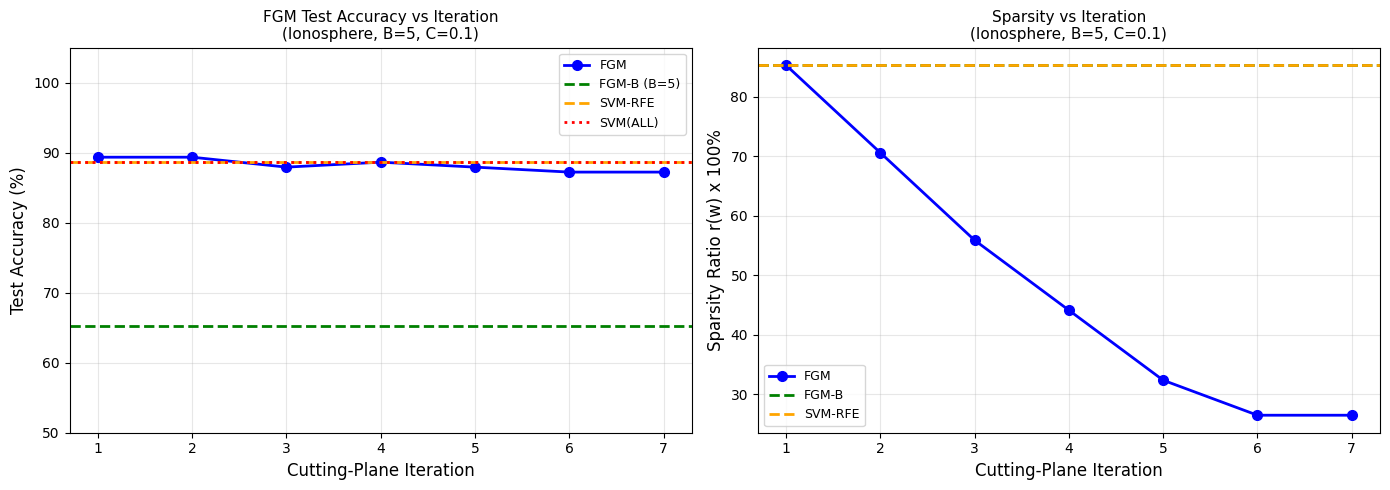

Plot saved to partB/results/task_2_2_fgm_results.png


In [8]:
# Visualisation: FGM accuracy + sparsity across iterations (mirrors Figures 2a-2b)
import os; os.makedirs('results', exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
iters = fgm_results['iteration']

ax = axes[0]
ax.plot(iters, fgm_results['test_acc'], 'b-o', lw=2, label='FGM', ms=7)
ax.axhline(fgmB_acc,        color='green',  ls='--', lw=2, label=f'FGM-B (B={B})')
ax.axhline(rfe_r['test_acc'], color='orange', ls='--', lw=2, label='SVM-RFE')
ax.axhline(all_acc,         color='red',    ls=':',  lw=2, label='SVM(ALL)')
ax.set_xlabel('Cutting-Plane Iteration', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title(f'FGM Test Accuracy vs Iteration\n(Ionosphere, B={B}, C={C})', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim([50, 105])

ax = axes[1]
ax.plot(iters, [s*100 for s in fgm_results['sparsity_ratio']], 'b-o', lw=2, label='FGM', ms=7)
ax.axhline(fgmB_spar*100,          color='green',  ls='--', lw=2, label='FGM-B')
ax.axhline(rfe_r['sparsity']*100,  color='orange', ls='--', lw=2, label='SVM-RFE')
ax.set_xlabel('Cutting-Plane Iteration', fontsize=12)
ax.set_ylabel('Sparsity Ratio r(w) x 100%', fontsize=12)
ax.set_title(f'Sparsity vs Iteration\n(Ionosphere, B={B}, C={C})', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/task_2_2_fgm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to partB/results/task_2_2_fgm_results.png")


**What the code does:** Reproduces the style of Figures 2a-2b: test accuracy and sparsity ratio across cutting-plane iterations with reference lines for all comparison methods. The key comparison is FGM/FGM-B vs SVM-RFE at the same sparsity level (same B).

*Paper reference: Figure 2a (testing accuracy), Figure 2b (sparsity ratio), Section 3.3 (results).*

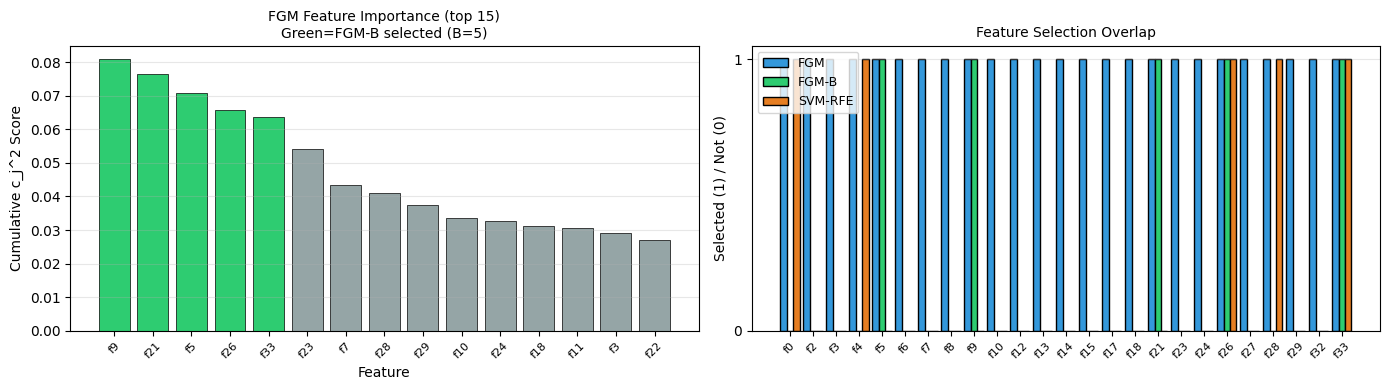

Feature selection plot saved.


In [9]:
# Feature importance bar plot and selection overlap
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
scores   = fgm_results['cumulative_scores']
si       = np.argsort(scores)[::-1][:15]
colors   = ['#2ecc71' if i < B else '#95a5a6' for i in range(15)]
ax.bar(range(15), scores[si], color=colors, edgecolor='black', lw=0.5)
ax.set_xticks(range(15))
ax.set_xticklabels([f'f{i}' for i in si], rotation=45, fontsize=8)
ax.set_xlabel('Feature'); ax.set_ylabel('Cumulative c_j^2 Score')
ax.set_title(f'FGM Feature Importance (top 15)\nGreen=FGM-B selected (B={B})', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
fgm_set  = set(fgm_results['final_features'])
fgmB_set = set(top_fgmB.tolist())
rfe_set  = set(rfe_r['selected_features'])
all_f    = sorted(fgm_set | fgmB_set | rfe_set)
x = np.arange(len(all_f)); w = 0.28
ax.bar(x-w, [1 if f in fgm_set  else 0 for f in all_f], w, label='FGM',     color='#3498db', ec='black')
ax.bar(x,   [1 if f in fgmB_set else 0 for f in all_f], w, label='FGM-B',   color='#2ecc71', ec='black')
ax.bar(x+w, [1 if f in rfe_set  else 0 for f in all_f], w, label='SVM-RFE', color='#e67e22', ec='black')
ax.set_xticks(x); ax.set_xticklabels([f'f{f}' for f in all_f], rotation=45, fontsize=8)
ax.set_ylabel('Selected (1) / Not (0)'); ax.set_title('Feature Selection Overlap', fontsize=10)
ax.legend(fontsize=9); ax.set_yticks([0,1]); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results/task_2_2_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature selection plot saved.")


**What the code does:** Two panels: (1) cumulative c_j^2 feature importance scores visualising the Section 2.4 scoring across all iterations; (2) grouped bar chart showing which features FGM, FGM-B, and SVM-RFE selected -- differences here demonstrate the non-monotonic vs monotonic property.

*Paper reference: Section 2.4 (c_j^2 scoring), Section 3.2 (FGM vs FGM-B vs SVM-RFE).*